In [1]:
from libraries import *

/opt/miniconda3/envs/py310/bin/python


In [44]:
skr_theory      = []
eta_theory      = []
if os.path.exists("skr_strato_data.pkl"):
    with open("skr_strato_data.pkl", "rb") as f:
        results = pickle.load(f)
    print(f"[INFO] Loaded checkpoint")

    # Iterate and access each entry
    for idx, entry in enumerate(results):
        d     = entry["d"]
        eta_t = entry["eta_t"] * 1e-2
        skr_t = entry["skr_t"] * 1e6

        print(
            f"{idx} -> d: {d}, eta_t: {eta_t},"
            f"skr_t: {skr_t}"
        )

        eta_theory.append(eta_t)
        skr_theory.append(skr_t)

[INFO] Loaded checkpoint
0 -> d: 25.0, eta_t: 0.26262729396998696,skr_t: 108289.76802594315
1 -> d: 24.673572926356734, eta_t: 0.26274335573936786,skr_t: 108337.62406517255
2 -> d: 24.281502625845828, eta_t: 0.26273858424329954,skr_t: 108335.65662228204
3 -> d: 24.00179048414567, eta_t: 0.2625328295594961,skr_t: 108250.8172796436
4 -> d: 23.81163749774391, eta_t: 0.2623099806366694,skr_t: 108158.92942673637
5 -> d: 23.78527670458881, eta_t: 0.26213097583521383,skr_t: 108085.11992989341
6 -> d: 23.81265289501545, eta_t: 0.2619187002322619,skr_t: 107997.59180037669
7 -> d: 23.8360793256977, eta_t: 0.261667868165729,skr_t: 107894.16558793809
8 -> d: 23.86143057818256, eta_t: 0.26143536387416444,skr_t: 107798.29651272521
9 -> d: 23.899352616510228, eta_t: 0.26115371464113346,skr_t: 107682.16338105955
10 -> d: 23.933178151059362, eta_t: 0.26083365975738815,skr_t: 107550.19435151799
11 -> d: 23.97050396509759, eta_t: 0.2605137595353961,skr_t: 107418.2890940434
12 -> d: 24.012707192355705, et

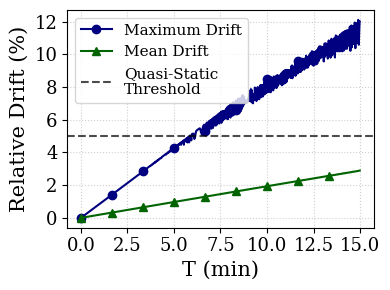

In [118]:
plt.rcParams['font.family']  = 'DeJavu Serif'
plt.rcParams['font.serif']   = ['Times New Roman']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42

def latlon_to_ecef(lat_deg, lon_deg, alt_m):
    R = 6371000  # Earth radius (m)
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    r = R + alt_m
    x = r * np.cos(lat) * np.cos(lon)
    y = r * np.cos(lat) * np.sin(lon)
    z = r * np.sin(lat)
    return np.column_stack((x, y, z))

# 1. Load Data
# Ensure the file path matches your environment
df = pd.read_csv("dataset/balloon_sim_data.csv")
df = df.sort_values("Time_s").drop_duplicates("Time_s").reset_index(drop=True)

# Define Ground Reference Point (First Lat/Lon, but Altitude = 0)
lat0, lon0 = df["Latitude_deg"].iloc[0], df["Longitude_deg"].iloc[0]
p_ref = latlon_to_ecef(lat0, lon0, 0)

# Define range for THETA (step size in seconds)
theta_values = np.arange(1, 900, 1) 
max_ratios = []
avg_ratios = []

for THETA in theta_values:
    # Downsample the data by picking every THETA-th point
    df_filtered = df.iloc[::THETA].copy()
    if len(df_filtered) < 2:
        max_ratios.append(np.nan)
        avg_ratios.append(np.nan)
        continue

    # Get HAP ECEF coordinates
    p_hap = latlon_to_ecef(
        df_filtered["Latitude_deg"], 
        df_filtered["Longitude_deg"], 
        df_filtered["Altitude_m"]
    )

    # 1-step displacement: Distance moved between consecutive downsampled points
    displacements = np.linalg.norm(np.diff(p_hap, axis=0), axis=1)
    
    # Distance from the ground station at the start of each step
    dist_from_ground = np.linalg.norm(p_hap[:-1] - p_ref, axis=1)

    # Calculate ratios (%)
    ratios = (displacements / dist_from_ground) * 100
    max_ratios.append(np.max(ratios))
    avg_ratios.append(np.mean(ratios))

max_ratios = np.array(max_ratios)
avg_ratios = np.array(avg_ratios)

# 2. Conversion and Threshold
theta_min = theta_values / 60  # Convert seconds to minutes for plotting
threshold = 5.0

# 3. Visualization
plt.figure(figsize=(4, 3)) # Increased height slightly for better readability

# Plotting against minutes
plt.plot(theta_min, max_ratios, color='navy', label='Maximum Drift', linewidth=1.5, marker="o", markevery=100)
plt.plot(theta_min, avg_ratios, color='darkgreen', label='Mean Drift', linewidth=1.5, marker="^", markevery=100)

plt.axhline(y=threshold, color='black', linestyle='--', label='Quasi-Static\nThreshold', alpha=0.7)

# Refined Labels
plt.xlabel("T (min)", fontsize=15)
plt.ylabel("Relative Drift (%)", fontsize=15)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("rel_drift.pdf", format='pdf', transparent=True, bbox_inches='tight', pad_inches=0.01)
plt.show()

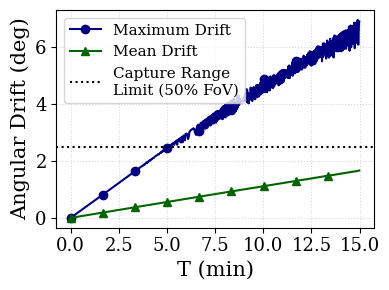

In [117]:
# 1. Load Data
df = pd.read_csv("dataset/balloon_sim_data.csv")
df = df.sort_values("Time_s").drop_duplicates("Time_s").reset_index(drop=True)

# Ground Station Reference
lat0, lon0 = df["Latitude_deg"].iloc[0], df["Longitude_deg"].iloc[0]
p_ref = latlon_to_ecef(lat0, lon0, 0)

# Define range for T (minutes)
theta_seconds = np.arange(1, 900, 1) # Testing up to 30 mins
max_angular_dev = []
avg_angular_dev = []

for s in theta_seconds:
    df_filtered = df.iloc[::s].copy()
    if len(df_filtered) < 2: continue

    p_hap = latlon_to_ecef(df_filtered["Latitude_deg"], df_filtered["Longitude_deg"], df_filtered["Altitude_m"])
    
    # Calculate angular displacement in Degrees
    # (displacement / slant_range) gives radians -> convert to degrees
    displacements = np.linalg.norm(np.diff(p_hap, axis=0), axis=1)
    slant_range = np.linalg.norm(p_hap[:-1] - p_ref, axis=1)
    
    angles_deg = np.degrees(displacements / slant_range)
    
    max_angular_dev.append(np.max(angles_deg))
    avg_angular_dev.append(np.mean(angles_deg))

# 2. Benchmarks (Bulletproof for MobiCom)
# Typical Coarse Tracking Camera FoV is ~5 degrees. 
# We want to stay well within the "Capture Range".
CAPTURE_RANGE_FOV = 5.0 
STABILITY_THRESHOLD = CAPTURE_RANGE_FOV * 0.5 # 2.5 degrees (50% of FoV)

# 3. Plotting
plt.figure(figsize=(4, 3))
t_min = theta_seconds / 60

plt.plot(t_min, max_angular_dev, color='navy', label='Maximum Drift', linewidth=1.5, marker="o", markevery=100)
plt.plot(t_min, avg_angular_dev, color='darkgreen', label='Mean Drift', linestyle='-', marker="^", markevery=100)

plt.axhline(y=STABILITY_THRESHOLD, color='black', linestyle=':', label='Capture Range\nLimit (50% FoV)')

plt.xlabel("T (min)", fontsize=15)
plt.ylabel("Angular Drift (deg)", fontsize=15)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=11)
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig("ang_drift.pdf", format='pdf', transparent=True, bbox_inches='tight', pad_inches=0.01)
plt.show()